<a href="https://colab.research.google.com/github/MariamF35/My_Projects/blob/main/SPAM_EMAIL_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPAM EMAIL CLASSIFICATION

In [190]:
import kagglehub
path = kagglehub.dataset_download('mfaisalqureshi/spam-email')

print('Data source import complete.')


Using Colab cache for faster access to the 'spam-email' dataset.
Data source import complete.


#Introduction

This notebook presents a **spam email classification** project that builds an end‑to‑end machine learning pipeline to distinguish unsolicited spam messages from legitimate (ham) emails using a real‑world SMS/email dataset. After exploring and cleaning the data, the messages are transformed into numerical features with TF‑IDF, and multiple models are trained and evaluated, including SVC, Logistic Regression, Decision Trees, Random Forests, ensemble methods, and XGBoost, with performance compared mainly on accuracy and precision. The best‑performing SVC model is then wrapped in a pipeline and tested on custom example emails to simulate real usage, demonstrating how text preprocessing and supervised learning can be combined to build a practical, high‑accuracy spam detection system.

In [191]:
#Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from sklearn.pipeline import Pipeline

In [192]:
df=pd.read_csv('/kaggle/input/spam-email/spam.csv') #loaded dataset into a dataframe

In [193]:
# check data
df.head() #prints first 5 rows

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [194]:
# check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [195]:
#check shape of data
df.shape

(5572, 2)

In [196]:
# check description
df.describe()

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [197]:
# check missing values
df.isnull().sum()

,0
Category,0
Message,0


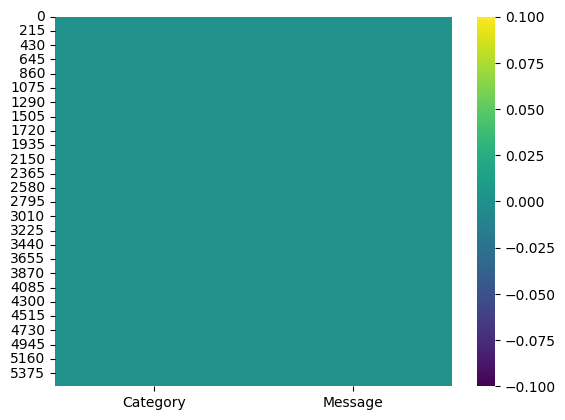

In [198]:
# Plot heat map for missing values
sns.heatmap(df.isnull(), cmap='viridis', cbar=True)
plt.show()

In [199]:
#check value count in cactegory column
df['Category'].value_counts()

,count
Category,
ham,4825
spam,747


In [200]:
#check value counts in percentage
df['Category'].value_counts()/len (df)*100

,count
Category,
ham,86.593683
spam,13.406317


<BarContainer object of 2 artists>

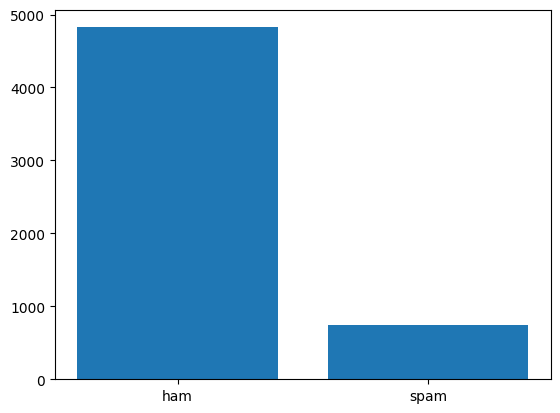

In [201]:
#visualization
plt.bar(['ham','spam'],df['Category'].value_counts())

<Axes: ylabel='count'>

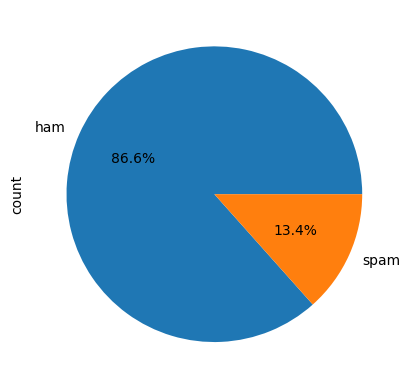

In [202]:
#pie chart representation
df['Category'].value_counts().plot(kind='pie',autopct='%1.1f%%')


In [203]:
#check Message column
df['Message']

,Message
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will ü b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


# Data Preprocessing: 🚧

In [204]:
# Data Preprocessing
#check duplicates in message
df.duplicated(subset='Message').sum()

np.int64(415)

In [205]:
#drop duplicates keep first
df.drop_duplicates(keep='first', inplace=True)

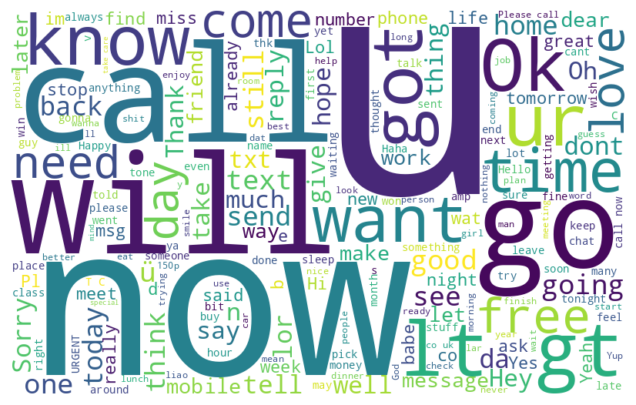

In [206]:
# check wordcloud
text=' '.join(df['Message'])
wordcloud=WordCloud(width=800,height=500,background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

In [207]:
# change text into lower
def lowerChange(text):
    return text.lower()

df['Message']=df['Message'].apply(lowerChange)
df['Message']

,Message
0,"go until jurong point, crazy.. available only ..."
1,ok lar... joking wif u oni...
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor... u c already then say...
4,"nah i don't think he goes to usf, he lives aro..."
...,...
5567,this is the 2nd time we have tried 2 contact u...
5568,will ü b going to esplanade fr home?
5569,"pity, * was in mood for that. so...any other s..."
5570,the guy did some bitching but i acted like i'd...


In [208]:
# Data Encoding
#covert ham into 1 and spam into 0
df['Category']=df['Category'].map({'ham':1,'spam':0})

In [209]:
df['Category'].value_counts()

,count
Category,
1,4516
0,641


_____

In [210]:
#split data into X and y
X=df['Message']
y=df['Category']

In [211]:
#Training the model
X_train1,X_test1,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

## TF-IDF (Term Frequency-Inverse Document Frequency)

In [212]:
# Initialize the TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Fit the vectorizer on the training data and transform the training data
X_train = vectorizer.fit_transform(X_train1)

# Transform the test data using the same vectorizer
X_test = vectorizer.transform(X_test1)


In [213]:
#Creating models
bc = BaggingClassifier(n_estimators=50, random_state=42)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=42)
xgb = XGBClassifier(n_estimators=50, random_state=42)
svc = SVC(kernel="sigmoid", gamma=1.0)
dtc = DecisionTreeClassifier(max_depth=10)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=42)
abc = AdaBoostClassifier(n_estimators=50, random_state=42)


models = {
    'BGC': bc,
    'GBDT': gbdt,
    'xgb': xgb,
    'SVC': svc,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'Adaboost': abc
}

def train_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision

In [214]:
%%time
accuracy_scores = []
precision_scores = []
models_names=[]

# Iterate over the items in the clfs dictionary
for name, model in models.items():
    current_accuracy, current_precision = train_classifier(model, X_train, y_train, X_test, y_test)
    rounded_accuracy = round(current_accuracy, 2)
    rounded_precision = round(current_precision, 2)

    print()
    print("For: ", name)
    print("Accuracy: ", rounded_accuracy)
    print("Precision: ", rounded_precision)

    accuracy_scores.append(rounded_accuracy)
    precision_scores.append(rounded_precision)
    models_names.append(name)



For:  BGC
Accuracy:  0.96
Precision:  0.97

For:  GBDT
Accuracy:  0.95
Precision:  0.95

For:  xgb
Accuracy:  0.97
Precision:  0.97

For:  SVC
Accuracy:  0.98
Precision:  0.98

For:  DT
Accuracy:  0.96
Precision:  0.97

For:  LR
Accuracy:  0.95
Precision:  0.96

For:  RF
Accuracy:  0.98
Precision:  0.98

For:  Adaboost
Accuracy:  0.94
Precision:  0.94
CPU times: user 18.8 s, sys: 21.5 ms, total: 18.8 s
Wall time: 18 s


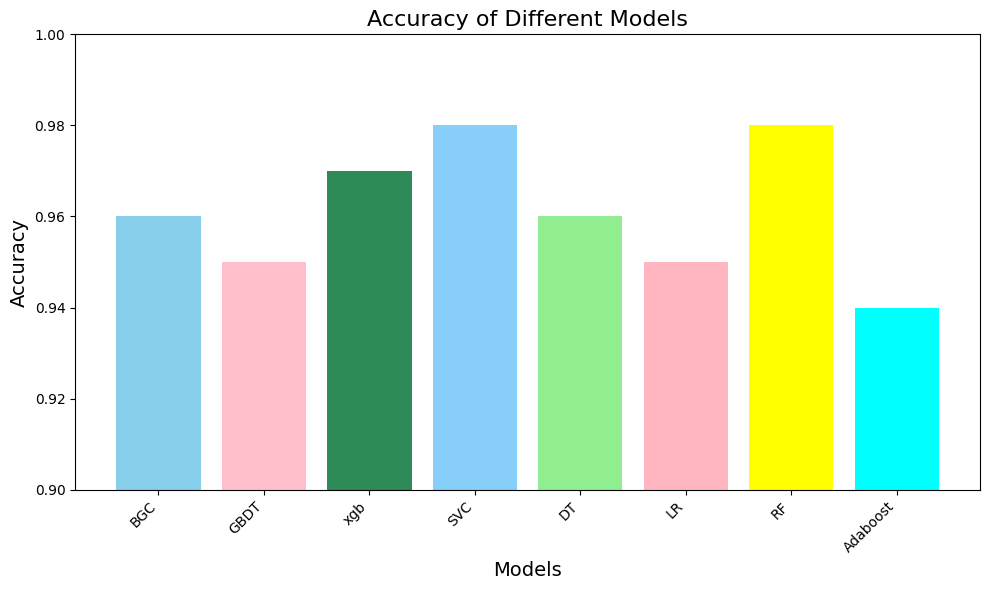

In [215]:
# Visualizing the best model
color = ['skyblue', 'pink', 'seagreen', 'lightskyblue', 'lightgreen', 'lightpink', 'yellow', 'cyan']

# Plot
plt.figure(figsize=(10, 6))
plt.bar(models_names, accuracy_scores, color=color)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Accuracy of Different Models', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.9, 1)  # Set the y-axis limits for better visualization
plt.tight_layout()
plt.show()

______

In [216]:
emails=[
    'Hey mohan, can we get together to watch footbal game tomorrow?',
    'hi, how are you?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!',
    'i won free vacation , you can win click below link',
    "Hey Sarah, are you available for a coffee chat this weekend?",
    "Congratulations! You've been selected as the winner of a $1000 cash prize. Click the link to claim your reward now!"
    'Claim your exclusive discount code now and save 30% on your next purchase! Limited time offer!',
    "You've won a luxury vacation package! Click the link to claim your prize and enjoy a dream getaway!",
    'Get rich quick with our investment opportunity! Join now and start earning big profits!',
    'Hey there, how about catching up for lunch this weekend? It\'s been a while since we last met!',
    'Reminder: Your appointment with the doctor is scheduled for tomorrow at 10 AM. Please remember to bring any necessary documents.',
    'Invitation: Join us for a team-building event this Friday at the local park. Food and games provided!'

]

In [217]:
# Create a new model with pipeline
SVC1 = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', SVC())
])

# Fit the model
SVC1.fit(X_train1, y_train)

Pipeline(steps=[('vectorizer', TfidfVectorizer()), ('classifier', SVC())])

In [218]:
emails=[
    'Hey mohan, can we get together to watch footbal game tomorrow?',
    'hi, how are you?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!',
    'i won free vacation , you can win click below link',
    "Hey Sarah, are you available for a coffee chat this weekend?",
    "Congratulations! You've been selected as the winner of a $1000 cash prize. Click the link to claim your reward now!"
    'Claim your exclusive discount code now and save 30% on your next purchase! Limited time offer!',
    "You've won a luxury vacation package! Click the link to claim your prize and enjoy a dream getaway!",
    'Get rich quick with our investment opportunity! Join now and start earning big profits!',
    'Hey there, how about catching up for lunch this weekend? It\'s been a while since we last met!',
    'Reminder: Your appointment with the doctor is scheduled for tomorrow at 10 AM. Please remember to bring any necessary documents.',
    'Invitation: Join us for a team-building event this Friday at the local park. Food and games provided!'

]

In [219]:
#predict new emails
templ=SVC1.predict(emails)
for email, label in zip(emails, templ):
  print(email,end="\t")
  if label:
    print('Spam')
  else:
    print('Ham')
  print()

Hey mohan, can we get together to watch footbal game tomorrow?	Spam

hi, how are you?	Spam

Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!	Spam

i won free vacation , you can win click below link	Ham

Hey Sarah, are you available for a coffee chat this weekend?	Spam

Congratulations! You've been selected as the winner of a $1000 cash prize. Click the link to claim your reward now!Claim your exclusive discount code now and save 30% on your next purchase! Limited time offer!	Ham

You've won a luxury vacation package! Click the link to claim your prize and enjoy a dream getaway!	Ham

Get rich quick with our investment opportunity! Join now and start earning big profits!	Spam

Hey there, how about catching up for lunch this weekend? It's been a while since we last met!	Spam

Reminder: Your appointment with the doctor is scheduled for tomorrow at 10 AM. Please remember to bring any necessary documents.	Spam

Invitation: Join us for a team-building event t

In [220]:
print("Accuracy = ",100*accuracy_score(SVC1.predict(X_test1),y_test))

Accuracy =  98.38501291989664


In [221]:
print("Precision = ",100*precision_score(SVC1.predict(X_test1),y_test))

Precision =  99.85130111524163


### Conclusion

In this notebook, we built a spam email classification system using a TF‑IDF representation of messages combined with several machine‑learning models, including SVC, Naive Bayes, decision trees, random forests, boosting methods, and XGBoost. After comparing performance across models using accuracy and precision, SVC and Random Forest achieved the strongest results, with SVC ultimately selected and deployed in a pipeline for real‑world style email inputs. The final SVC pipeline reached about 98.4% accuracy and 99.85% precision on the test set, showing that the model can reliably distinguish spam from legitimate emails while keeping false positives very low. This demonstrates that TF‑IDF features combined with a well‑tuned SVC classifier provide an effective solution for spam detection on this dataset and can be extended to similar text‑classification tasks with appropriate preprocessing and evaluation.